# Causal Inference for AI — Week 3
## Estimation under Unconfoundedness: Propensity Scores, IPW, Matching & Doubly-Robust AIPW

We have an estimand (Week 1) and we know which covariates to condition on (Week 2). This
week we build the **workhorse estimators** that turn that knowledge into a number, all from
scratch on a confounded simulator with a known ATE:

1. The **propensity score** $e(x)=P(T{=}1\mid X{=}x)$ and Rosenbaum–Rubin's balancing theorem.
2. **Inverse-Propensity Weighting (IPW)** and its stabilized/Hájek variant.
3. **Nearest-neighbour matching** on the propensity score.
4. The **doubly-robust AIPW** estimator and a demonstration of its defining property:
   consistency if *either* the outcome model *or* the propensity model is correct.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = default_rng(0)
print("Environment ready — NumPy", np.__version__)

Environment ready — NumPy 2.4.4


In [2]:
def make_data(n=8000, seed=0):
    """Confounded world with KNOWN ATE. Two covariates drive selection & outcome."""
    g = default_rng(seed)
    X1 = g.normal(0, 1, n)
    X2 = g.normal(0, 1, n)
    X = np.column_stack([X1, X2])

    # True propensity: nonlinear in X
    lin = 0.8*X1 - 0.6*X2 + 0.4*X1*X2
    e = 1/(1+np.exp(-lin))
    T = (g.uniform(size=n) < e).astype(int)

    tau = 3.0                                  # CONSTANT true effect => ATE = 3
    mu0 = 1.0 + 2.0*X1 + 1.0*X2 + 0.5*X1**2     # baseline outcome surface
    Y0 = mu0 + g.normal(0, 1, n)
    Y1 = Y0 + tau
    Y = np.where(T==1, Y1, Y0)
    return X, T, Y, e, tau

X, T, Y, e_true, ATE = make_data()
naive = Y[T==1].mean() - Y[T==0].mean()
print(f"True ATE          : {ATE:.3f}")
print(f"Naive diff-in-means: {naive:.3f}   (bias {naive-ATE:+.3f})")
print(f"Treated fraction  : {T.mean():.3f}")

True ATE          : 3.000
Naive diff-in-means: 3.905   (bias +0.905)
Treated fraction  : 0.509


## 1. The propensity score, estimated from scratch

We fit logistic regression by Newton–Raphson / IRLS — no `sklearn`. The **balancing
property** (Rosenbaum & Rubin, 1983) says conditioning on the scalar $e(X)$ is enough to
remove confounding due to $X$: $\;T \perp\!\!\!\perp X \mid e(X)$. We will check overlap,
the single most important diagnostic.

corr(estimated e, true e): 0.999


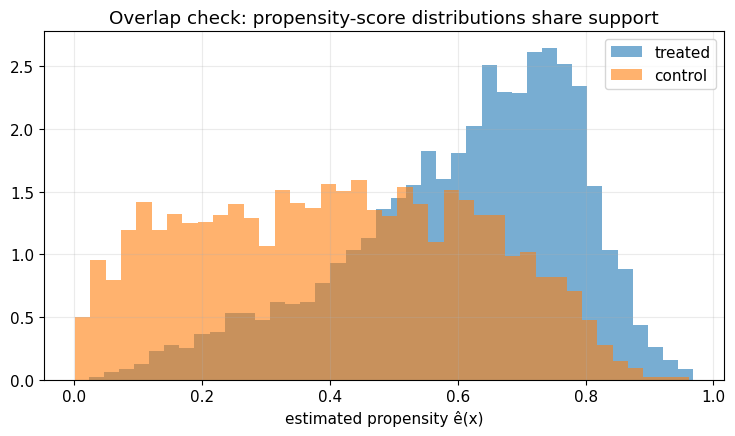

In [3]:
def logistic_irls(X, y, iters=50, tol=1e-10):
    Xd = np.column_stack([np.ones(len(X)), X])
    beta = np.zeros(Xd.shape[1])
    for _ in range(iters):
        eta = Xd @ beta
        p = 1/(1+np.exp(-eta))
        W = p*(1-p) + 1e-9
        grad = Xd.T @ (y - p)
        H = Xd.T @ (Xd * W[:,None])
        step = np.linalg.solve(H, grad)
        beta += step
        if np.max(np.abs(step)) < tol: break
    return beta

def propensity(X, T):
    # include an interaction term so the model can capture the true nonlinearity
    feats = np.column_stack([X, X[:,0]*X[:,1]])
    beta = logistic_irls(feats, T)
    eta = np.column_stack([np.ones(len(feats)), feats]) @ beta
    return 1/(1+np.exp(-eta))

ehat = propensity(X, T)
print(f"corr(estimated e, true e): {np.corrcoef(ehat, e_true)[0,1]:.3f}")

plt.hist(ehat[T==1], bins=40, alpha=.6, density=True, label="treated")
plt.hist(ehat[T==0], bins=40, alpha=.6, density=True, label="control")
plt.title("Overlap check: propensity-score distributions share support")
plt.xlabel("estimated propensity ê(x)"); plt.legend()
plt.tight_layout(); plt.savefig("../figures/w3_overlap.png", dpi=110); plt.show()

## 2. Inverse-Propensity Weighting (IPW)

IPW reweights units to build a *pseudo-population* in which treatment is independent of
covariates. The **Horvitz–Thompson** estimator:

$$ \hat\tau_{\text{IPW}} = \frac1n\sum_i \frac{T_iY_i}{\hat e(x_i)} - \frac1n\sum_i\frac{(1-T_i)Y_i}{1-\hat e(x_i)}. $$

The **stabilized / Hájek** version normalizes the weights and is far less volatile when
some propensities are near 0 or 1:

$$ \hat\tau_{\text{Hájek}} = \frac{\sum_i T_iY_i/\hat e_i}{\sum_i T_i/\hat e_i}
   - \frac{\sum_i (1-T_i)Y_i/(1-\hat e_i)}{\sum_i (1-T_i)/(1-\hat e_i)}. $$

In [4]:
def ipw_ht(Y, T, e):
    return (T*Y/e).mean() - ((1-T)*Y/(1-e)).mean()

def ipw_hajek(Y, T, e):
    w1, w0 = T/e, (1-T)/(1-e)
    return (w1*Y).sum()/w1.sum() - (w0*Y).sum()/w0.sum()

# clip propensities for numerical safety (a standard practical choice)
ec = np.clip(ehat, 0.02, 0.98)
print(f"True ATE              : {ATE:.3f}")
print(f"IPW (Horvitz-Thompson): {ipw_ht(Y,T,ec):.3f}")
print(f"IPW (stabilized/Hájek): {ipw_hajek(Y,T,ec):.3f}")

# Diagnostic: effective sample size of the weights tells us how unstable IPW is.
w = np.where(T==1, 1/ec, 1/(1-ec))
ess = w.sum()**2 / (w**2).sum()
print(f"Effective sample size : {ess:.0f} / {len(Y)}  ({100*ess/len(Y):.1f}% of nominal)")

True ATE              : 3.000
IPW (Horvitz-Thompson): 2.961
IPW (stabilized/Hájek): 2.975
Effective sample size : 5487 / 8000  (68.6% of nominal)


### Checking covariate balance after weighting

A weighting scheme is only as good as the balance it achieves. We compute the
**standardized mean difference (SMD)** of each covariate before and after weighting; a
common rule of thumb is $|\text{SMD}| < 0.1$ indicates good balance.

In [5]:
def smd(x, T, w=None):
    if w is None: w = np.ones_like(x, float)
    def wm(mask): return np.average(x[mask], weights=w[mask])
    def wv(mask): 
        m = wm(mask); 
        return np.average((x[mask]-m)**2, weights=w[mask])
    m1, m0 = wm(T==1), wm(T==0)
    s = np.sqrt(0.5*(wv(T==1)+wv(T==0)))
    return (m1-m0)/s

w_ipw = np.where(T==1, 1/ec, 1/(1-ec))
print("Covariate   SMD before   SMD after IPW")
for j, name in enumerate(["X1","X2"]):
    print(f"  {name:8s}  {smd(X[:,j],T):+8.3f}   {smd(X[:,j],T,w_ipw):+8.3f}")
print("\nWeighting drives the standardized differences toward zero -> confounding removed.")

Covariate   SMD before   SMD after IPW
  X1          +0.725     +0.009
  X2          -0.510     +0.001

Weighting drives the standardized differences toward zero -> confounding removed.


## 3. Propensity-score matching from scratch

Matching pairs each treated unit with the control whose propensity score is closest,
estimating the **ATT**. We implement 1-nearest-neighbour matching with replacement directly
on $\hat e(x)$.

In [6]:
def nn_match_att(Y, T, e):
    treated = np.where(T==1)[0]
    control = np.where(T==0)[0]
    ec_ = e[control]
    diffs = []
    for i in treated:
        j = control[np.argmin(np.abs(ec_ - e[i]))]   # nearest control by propensity
        diffs.append(Y[i] - Y[j])
    return np.mean(diffs)

att_match = nn_match_att(Y, T, ec)
# Since the true effect is constant, ATT == ATE == 3 here.
print(f"True ATT (= ATE, constant effect): {ATE:.3f}")
print(f"NN propensity matching estimate  : {att_match:.3f}")

True ATT (= ATE, constant effect): 3.000
NN propensity matching estimate  : 3.059


## 4. The outcome-regression / g-computation estimator

Complementary to IPW: fit $\hat\mu_t(x)=\hat{\mathbb{E}}[Y\mid T{=}t,X{=}x]$ and average the
predicted contrast — the g-formula from Week 1, now with separate models per arm.

In [7]:
def ols_fit(Xmat, y):
    Xd = np.column_stack([np.ones(len(Xmat)), Xmat])
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    return beta
def ols_pred(beta, Xmat):
    return np.column_stack([np.ones(len(Xmat)), Xmat]) @ beta

# Use a quadratic basis so the model can represent the X1^2 term in the truth.
def basis(X): return np.column_stack([X, X[:,0]**2, X[:,1]**2, X[:,0]*X[:,1]])
B = basis(X)
b1 = ols_fit(B[T==1], Y[T==1])
b0 = ols_fit(B[T==0], Y[T==0])
mu1 = ols_pred(b1, B)
mu0 = ols_pred(b0, B)
g_ate = (mu1 - mu0).mean()
print(f"True ATE              : {ATE:.3f}")
print(f"Outcome-regression ATE: {g_ate:.3f}")

True ATE              : 3.000
Outcome-regression ATE: 2.999


## 5. Doubly-robust AIPW — the headline estimator

The **Augmented IPW** estimator combines the outcome model and the propensity model:

$$ \hat\tau_{\text{AIPW}} = \frac1n\sum_i\Big[ \hat\mu_1(x_i)-\hat\mu_0(x_i)
   + \frac{T_i\big(Y_i-\hat\mu_1(x_i)\big)}{\hat e(x_i)}
   - \frac{(1-T_i)\big(Y_i-\hat\mu_0(x_i)\big)}{1-\hat e(x_i)} \Big]. $$

Its remarkable **double-robustness**: $\hat\tau_{\text{AIPW}}$ is consistent if **either**
$\hat\mu_t$ **or** $\hat e$ is correctly specified — you get two shots at the truth. We
prove this empirically by deliberately *breaking* each nuisance model in turn.

In [8]:
def aipw(Y, T, e, mu1, mu0):
    aug = (mu1 - mu0) + T*(Y-mu1)/e - (1-T)*(Y-mu0)/(1-e)
    est = aug.mean()
    se = aug.std(ddof=1)/np.sqrt(len(aug))      # influence-function-based SE
    return est, se

est, se = aipw(Y, T, ec, mu1, mu0)
print(f"True ATE        : {ATE:.3f}")
print(f"AIPW estimate   : {est:.3f}  ±{1.96*se:.3f} (95% CI)")
print(f"95% CI          : [{est-1.96*se:.3f}, {est+1.96*se:.3f}]")

True ATE        : 3.000
AIPW estimate   : 2.984  ±0.054 (95% CI)
95% CI          : [2.930, 3.038]


In [9]:
# --- Double-robustness stress test --------------------------------------------
# WRONG outcome model: intercept-only (ignores all covariates).
mu1_bad = np.full(len(Y), Y[T==1].mean())
mu0_bad = np.full(len(Y), Y[T==0].mean())
# WRONG propensity model: constant 0.5 (ignores confounding).
e_bad = np.full(len(Y), 0.5)

scenarios = {
    "both correct"            : (ec,    mu1,     mu0),
    "outcome WRONG, prop OK"  : (ec,    mu1_bad, mu0_bad),
    "outcome OK, prop WRONG"  : (e_bad, mu1,     mu0),
    "both WRONG"              : (e_bad, mu1_bad, mu0_bad),
}
print(f"{'scenario':28s} AIPW est   IPW-only   OutReg-only")
for name,(ee,m1,m0) in scenarios.items():
    a,_ = aipw(Y,T,ee,m1,m0)
    ipw_only = ipw_ht(Y,T,ee)
    reg_only = (m1-m0).mean()
    print(f"{name:28s} {a:7.3f}   {ipw_only:7.3f}    {reg_only:7.3f}")
print(f"\n(true ATE = {ATE}). AIPW stays accurate whenever AT LEAST ONE model is correct;")
print("it fails only when BOTH are wrong — exactly the double-robustness guarantee.")

scenario                     AIPW est   IPW-only   OutReg-only
both correct                   2.984     2.961      2.999
outcome WRONG, prop OK         2.976     2.961      3.905
outcome OK, prop WRONG         2.999     4.017      2.999
both WRONG                     3.905     4.017      3.905

(true ATE = 3.0). AIPW stays accurate whenever AT LEAST ONE model is correct;
it fails only when BOTH are wrong — exactly the double-robustness guarantee.


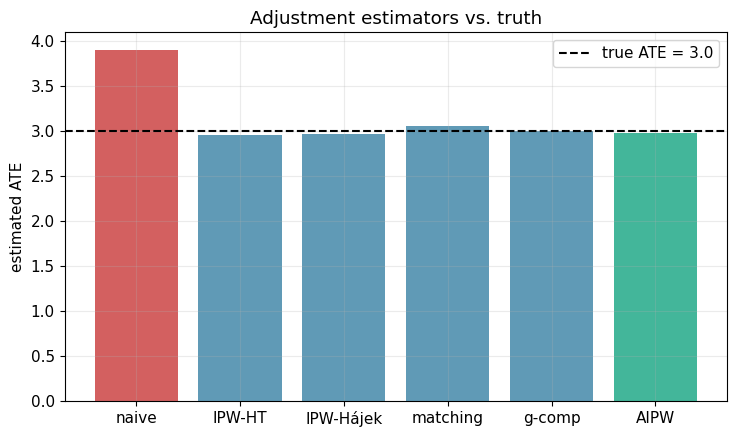

In [10]:
# Visual summary of all estimators on the correctly-specified problem.
methods = ["naive", "IPW-HT", "IPW-Hájek", "matching", "g-comp", "AIPW"]
ests = [naive, ipw_ht(Y,T,ec), ipw_hajek(Y,T,ec), att_match, g_ate, est]
colors = ["#c44"] + ["#48a"]*4 + ["#2a8"]
plt.bar(methods, ests, color=colors, alpha=.85)
plt.axhline(ATE, color="k", ls="--", label=f"true ATE = {ATE}")
plt.ylabel("estimated ATE"); plt.legend(); plt.title("Adjustment estimators vs. truth")
plt.tight_layout(); plt.savefig("../figures/w3_estimators.png", dpi=110); plt.show()

## Summary & what's next

- The **propensity score** is a scalar balancing variable; we fit it with IRLS and checked
  overlap and post-weighting covariate balance (SMD).
- **IPW** builds a pseudo-population; the **stabilized/Hájek** form tames variance, and the
  **effective sample size** diagnoses weight instability.
- **Matching** and **g-computation** offer alternative routes to the same estimand.
- **AIPW** is **doubly robust**: our stress test showed it recovers the ATE whenever
  *either* nuisance model is right, failing only when both are wrong.

**Exercises.** (1) Add propensity trimming and plot bias–variance as a function of the clip
threshold. (2) Bootstrap the matching estimator for a CI and compare with AIPW's
influence-function SE. (3) Make the true effect heterogeneous and show ATT ≠ ATE again.

**Week 4:** AIPW's nuisance models can be *any* ML regressor — but naive plug-in induces
**regularization bias**. We fix it with **cross-fitting** and arrive at **Double Machine
Learning**.